In [ ]:
# import the datasets library from the Hugging Face hub
from datasets import load_dataset

# load the EuroSAT RGB dataset and inspect its structure
ds = load_dataset("blanchon/EuroSAT_RGB")
print(ds)

# retrieve label names from the training split and count classes
label_names = ds["train"].features["label"].names
num_classes = len(label_names)
print("Classes:", num_classes, label_names)

# print the number of samples in each dataset split
print("Split sizes:",
      len(ds["train"]), len(ds["validation"]), len(ds["test"]))

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})
Classes: 10 ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']
Split sizes: 16200 5400 5400


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# constants for image processing and batching
IMG_SIZE = (224, 224)          # target size expected by MobileNetV2
BATCH = 32                     # batch size for training/inference
AUTOTUNE = tf.data.AUTOTUNE    # let tf.data decide on parallelism

def make_tfds(split, training=False):
    """
    Convert a HuggingFace dataset split into a tf.data.Dataset.

    Arguments:
        split (str): one of "train", "validation", "test".
        training (bool): whether to shuffle for training.

    Returns:
        tf.data.Dataset ready for model training/evaluation.
    """
    # create a tf.data dataset yielding (image, label) pairs
    tfds = ds[split].to_tf_dataset(
        columns=["image"],
        label_cols=["label"],
        shuffle=training,
        batch_size=BATCH,
    )

    # resize and preprocess images, and cast types appropriately
    tfds = tfds.map(
        lambda x, y: (tf.image.resize(x, IMG_SIZE), y),
        num_parallel_calls=AUTOTUNE
    )

    tfds = tfds.map(
        lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), tf.cast(y, tf.int32)),
        num_parallel_calls=AUTOTUNE
    )

    # prefetch batches for performance
    return tfds.prefetch(AUTOTUNE)

# prepare datasets for each split
train_ds = make_tfds("train", training=True)
val_ds   = make_tfds("validation")
test_ds  = make_tfds("test")

/Users/samtouahri/anaconda3/envs/seg4180a6/lib/python3.10/site-packages/datasets/arrow_dataset.py:405: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


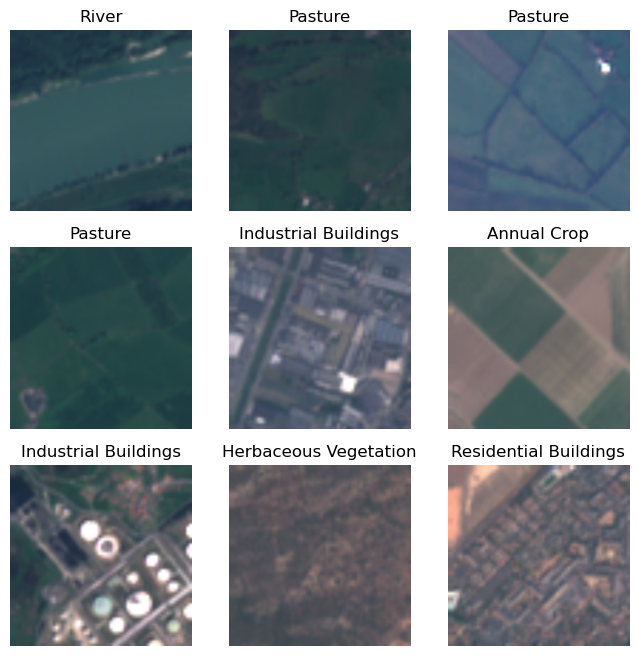

In [ ]:
import matplotlib.pyplot as plt

# visualize a few training examples to verify preprocessing
for xb, yb in train_ds.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        # reverse the MobileNetV2 preprocessing for display purposes
        img = (xb[i].numpy() + 1.0) * 127.5
        img = img.astype("uint8")
        plt.imshow(img)
        plt.title(label_names[int(yb[i])])
        plt.axis("off")
    plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

# load pretrained MobileNetV2 without the top classification layer
base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False  # freeze all convolutional weights for stage 1

# build a new classification head on top of the base model
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base(inputs, training=False)                     # use base in inference mode
x = layers.GlobalAveragePooling2D()(x)               # pool spatial features
x = layers.Dense(128, activation="relu")(x)        # add a hidden layer
x = layers.Dropout(0.3)(x)                           # regularization
outputs = layers.Dense(num_classes, activation="softmax")(x)  # final softmax

model = Model(inputs, outputs)

# compile the model with a reasonable optimizer and loss for multiclass
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                1290

In [ ]:
## Training stage 1: only train the new classification head

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.2),
]

hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
507/507 [==============================] - 142s 280ms/step - loss: 0.0657 - accuracy: 0.9785 - val_loss: 0.1607 - val_accuracy: 0.9454 - lr: 2.0000e-04
Epoch 2/10
507/507 [==============================] - 156s 307ms/step - loss: 0.0588 - accuracy: 0.9810 - val_loss: 0.1606 - val_accuracy: 0.9470 - lr: 2.0000e-04
Epoch 3/10
507/507 [==============================] - 168s 332ms/step - loss: 0.0554 - accuracy: 0.9814 - val_loss: 0.1583 - val_accuracy: 0.9496 - lr: 2.0000e-04
Epoch 4/10
507/507 [==============================] - 152s 300ms/step - loss: 0.0530 - accuracy: 0.9836 - val_loss: 0.1613 - val_accuracy: 0.9480 - lr: 2.0000e-04
Epoch 5/10
507/507 [==============================] - 169s 333ms/step - loss: 0.0502 - accuracy: 0.9834 - val_loss: 0.1629 - val_accuracy: 0.9478 - lr: 2.0000e-04
Epoch 6/10
507/507 [==============================] - 147s 289ms/step - loss: 0.0417 - accuracy: 0.9873 - val_loss: 0.1627 - val_accuracy: 0.9491 - lr: 4.0000e-05


In [ ]:
## fine tuning stage: unfreeze part of the base model for more learning

# set the base model trainable and freeze first 80% of layers
base.trainable = True
cut = int(len(base.layers) * 0.8)  # freeze first 80%
for layer in base.layers[:cut]:
    layer.trainable = False

# recompile with a lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
507/507 [==============================] - 258s 505ms/step - loss: 0.0822 - accuracy: 0.9707 - val_loss: 0.1601 - val_accuracy: 0.9491 - lr: 1.0000e-05
Epoch 2/5
507/507 [==============================] - 262s 517ms/step - loss: 0.0657 - accuracy: 0.9785 - val_loss: 0.1878 - val_accuracy: 0.9435 - lr: 1.0000e-05
Epoch 3/5
507/507 [==============================] - 244s 481ms/step - loss: 0.0586 - accuracy: 0.9796 - val_loss: 0.1779 - val_accuracy: 0.9504 - lr: 1.0000e-05
Epoch 4/5
507/507 [==============================] - 399s 788ms/step - loss: 0.0293 - accuracy: 0.9904 - val_loss: 0.1506 - val_accuracy: 0.9589 - lr: 2.0000e-06
Epoch 5/5
507/507 [==============================] - 364s 719ms/step - loss: 0.0268 - accuracy: 0.9904 - val_loss: 0.1440 - val_accuracy: 0.9578 - lr: 2.0000e-06


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# run inference on the test set and collect predictions
y_true, y_pred = [], []

for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true.extend(yb.numpy().tolist())
    y_pred.extend(preds.tolist())

# print a detailed classification report
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

# compute the confusion matrix for later plotting
cm = confusion_matrix(y_true, y_pred)

                       precision    recall  f1-score   support

          Annual Crop     0.9441    0.9631    0.9535       596
               Forest     0.9537    0.9819    0.9676       608
Herbaceous Vegetation     0.9294    0.9424    0.9359       573
              Highway     0.9224    0.9113    0.9168       496
 Industrial Buildings     0.9704    0.9820    0.9762       501
              Pasture     0.9468    0.8990    0.9223       396
       Permanent Crop     0.9395    0.9238    0.9316       538
Residential Buildings     0.9819    0.9819    0.9819       554
                River     0.9064    0.9149    0.9106       529
              SeaLake     0.9916    0.9688    0.9801       609

             accuracy                         0.9493      5400
            macro avg     0.9486    0.9469    0.9476      5400
         weighted avg     0.9494    0.9493    0.9492      5400



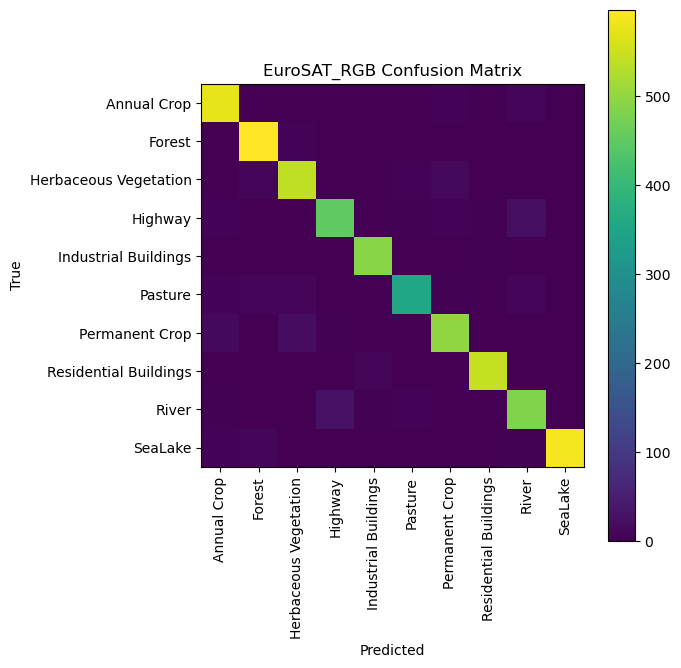

In [ ]:
import matplotlib.pyplot as plt

# display the confusion matrix as an image with labels
plt.figure(figsize=(7, 7))
plt.imshow(cm)
plt.title("EuroSAT_RGB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(num_classes), label_names, rotation=90)
plt.yticks(range(num_classes), label_names)
plt.tight_layout()
plt.show()

In [ ]:
# placeholder for additional analysis (currently empty)

In [ ]:
# another empty cell reserved for experiments

In [ ]:
# empty cell for separation or notes

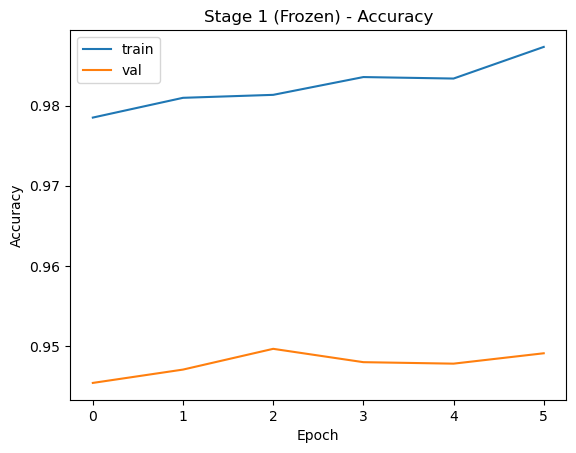

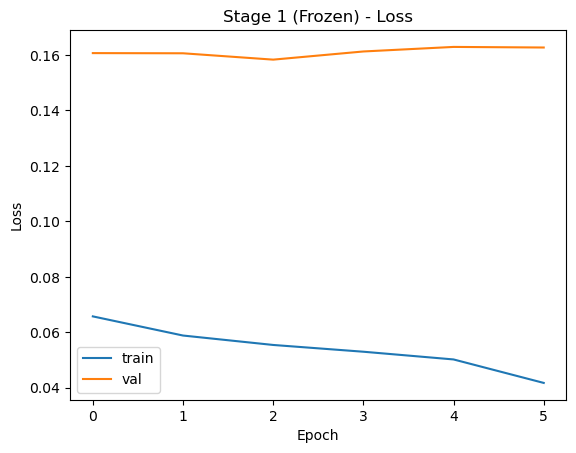

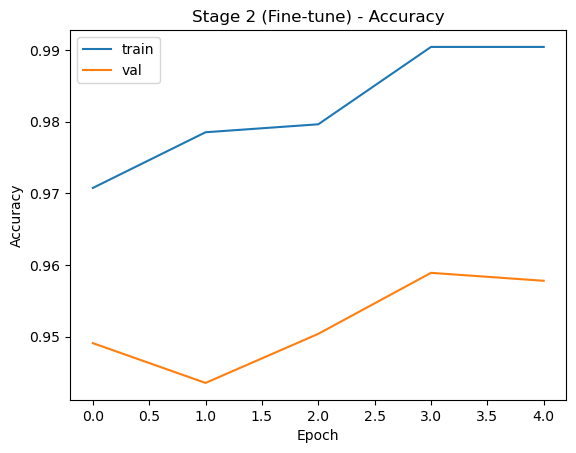

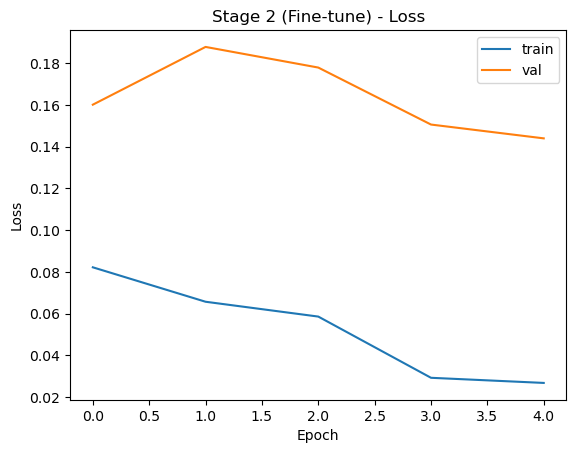

In [ ]:
def plot_history(h, title):
    # plot accuracy curves
    plt.figure()
    plt.plot(h.history["accuracy"])
    plt.plot(h.history["val_accuracy"])
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["train", "val"])
    plt.show()

    # plot loss curves
    plt.figure()
    plt.plot(h.history["loss"])
    plt.plot(h.history["val_loss"])
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["train", "val"])
    plt.show()

# visualize training history for both stages
plot_history(hist1, "Stage 1 (Frozen)")
plot_history(hist2, "Stage 2 (Fine-tune)")

In [ ]:
# final cell intentionally left blank